In [6]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

import lazypredict 
from lazypredict import Supervised 
from lazypredict.Supervised import LazyClassifier
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
plt.style.use('fivethirtyeight')
plt.rcParams["figure.figsize"] = (10,5)
import pandas as pd
import numpy as np

# Load libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn import datasets
# Import train_test_split function
from sklearn.model_selection import train_test_split
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

from sklearn.metrics import classification_report

import imblearn #should be install globally
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Apply SVM Model
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import auc,roc_auc_score,roc_curve
from sklearn.feature_selection import SelectKBest,SelectPercentile,f_classif,f_regression,mutual_info_regression,mutual_info_classif,SelectFromModel,RFE


In [7]:
random_state = 42

In [8]:
data_path = "data/noOutliers-data4-completely.csv"
data = pd.read_csv(data_path)
data.shape

(369, 19)

In [9]:
data.columns

Index(['KIR2DL4', 'CX3CR1', 'KLRF1', 'KIR3DL1', 'KLRC4', 'FGFBP2', 'KIR2DL1',
       'GNLY', 'MMP9', 'MMP3', 'COL3A1', 'SPP1', 'POSTN', 'COL1A1', 'IGF1',
       'MMP2', 'MMP1', 'COL1A2', 'Outcomes'],
      dtype='object')

In [10]:
#data splitting Pipeline,  labels and features

cols_labels = data.columns.tolist()
cols_labels.pop(-1)

data_features = pd.read_csv(data_path, usecols = cols_labels)

data_labels = pd.read_csv(data_path, usecols = ['Outcomes'])

In [11]:
X_new = data_features

In [12]:
#X = np.asarray(data_features)
#y = np.asarray(data_labels)
X = data_features
X = StandardScaler().fit_transform(X)
X = pd.DataFrame(X, columns=X_new.columns)
#data.shape

y = data_labels
#X = preprocessing.scale(X)

#X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [13]:
print("X_train.shape: ", X_train.shape)
print("y_train.shape: ", y_train.shape)
print("X_test.shape: ", X_test.shape)
print("y_test.shape: ", y_test.shape)

X_train.shape:  (295, 18)
y_train.shape:  (295, 1)
X_test.shape:  (74, 18)
y_test.shape:  (74, 1)


In [14]:
count_1 = y_test['Outcomes'].eq(1).sum()
count_0 = y_test['Outcomes'].eq(0).sum()
print("count_1: ", count_1)
print("count_0: ", count_0)

count_1:  42
count_0:  32


In [15]:
Kbest_classif = SelectKBest(score_func=f_classif, k=7)
Kbest_classif.fit(X_train, y_train)

# what are scores for the features
#for i in range(len(Kbest_classif.scores_)):
#    print(f'Feature {i} : {round(Kbest_classif.scores_[i],3)}')



SelectKBest(k=7)

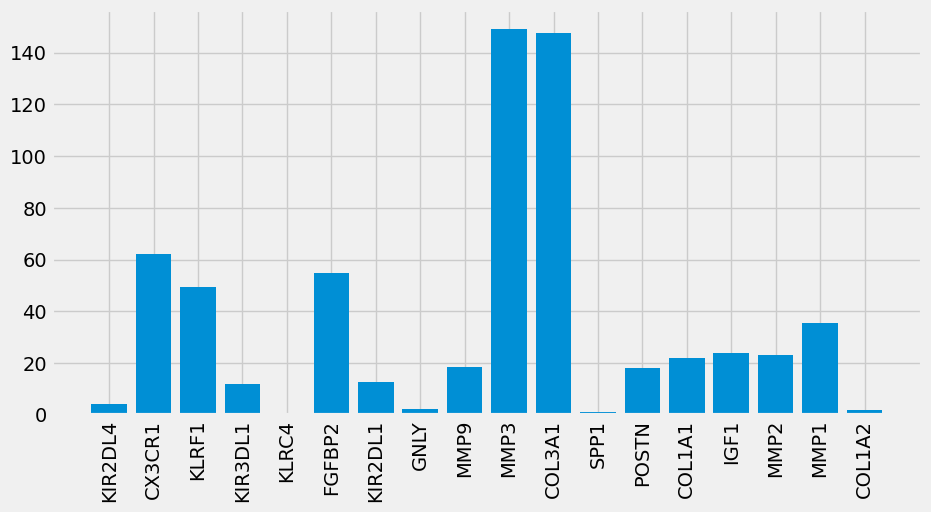

In [16]:
plt.bar([X_train.columns[i] for i in range(len(Kbest_classif.scores_))], Kbest_classif.scores_)
plt.xticks(rotation=90)
plt.rcParams["figure.figsize"] = (8,6)
plt.show()

In [21]:
data.columns

Index(['L3MBTL1', 'BRCC3', 'SP1', 'WASH3P', 'MRPL40', 'PMEL', 'ADAMTSL5',
       'MORF4L1', 'PCYT2', 'BCAP31', 'GNB1L', 'DNAH14', 'THNSL1', 'SETD4',
       'PTCH1', 'RNPC3', 'IRS2', 'Outcomes'],
      dtype='object')

In [25]:
# transform training set
X_train_classif = Kbest_classif.transform(X_train)
print("X_train.shape: {}".format(X_train.shape))
print("X_train_selected.shape: {}".format(X_train_classif.shape))

# transform test data
X_test_classif = Kbest_classif.transform(X_test)

X_train.shape: (86, 6972)
X_train_selected.shape: (86, 300)


In [46]:
# Get the indices of the selected features
selected_features_indices = Kbest_classif.get_support()

# Get the names of the selected features
selected_feature_names = X_train.columns[selected_features_indices]

# Print or use the selected feature names
print("Selected Feature Names:", selected_feature_names)

Selected Feature Names: Index(['RCN3', 'PRDM16', 'SH3BGRL3', 'CYR61', 'LMO4', 'POU2F1', 'POGZ',
       'GOLPH3L', 'C1orf35', 'EPHX1',
       ...
       'SIX6', 'EFNA5', 'CSF1', 'TUSC5', 'ARMCX2', 'RBM43', 'IMMP2L',
       'WBSCR17', 'OLFML2A', 'PCGF3'],
      dtype='object', length=300)


In [48]:
selected_features = X_new[selected_feature_names]

In [49]:
selected_features.shape

(108, 300)

In [50]:
selected_features.head(5)

,RCN3,PRDM16,SH3BGRL3,CYR61,LMO4,POU2F1,POGZ,GOLPH3L,C1orf35,EPHX1,...,SIX6,EFNA5,CSF1,TUSC5,ARMCX2,RBM43,IMMP2L,WBSCR17,OLFML2A,PCGF3
0,5014,289,9546,1401,751,1290,457,3,222,2846,...,0,196,45517,1,1182,226,761,487,49,2
1,7,0,7070,11,7769,3,8,2,0,1992,...,0,14,12578,0,8,2,0,5,0,0
2,150,492,13146,2,441,247,842,883,387,220,...,0,5,7256,0,1,39,623,1,2,129
3,5,1,4028,0,52,1112,15,2304,1381,191,...,0,7,2092,0,1,4,0,1,0,1
4,4462,0,4426,15,3038,0,5,904,1,4713,...,2,187,32120,0,1898,1326,962,0,1852,2333


In [ ]:
top_features = list(selected_features.columns)
top_features.append('Outcomes')
top_features

In [52]:
selected_features['Outcomes'] = data['Outcomes']

In [56]:
selected_features.to_csv('data/kbest300.csv', index=False)

In [57]:
from sklearn.metrics import auc,roc_auc_score,roc_curve

In [58]:
best_est =  RandomForestClassifier(random_state=42, criterion= 'gini', max_depth=4, n_estimators=50)

best_est = best_est.fit(X_train[selected_feature_names],y_train)
train_fpr, train_tpr, thresholds = roc_curve(y_train, best_est.predict_proba(X_train[selected_feature_names])[:,1])
test_fpr, test_tpr, thresholds = roc_curve(y_test, best_est.predict_proba(X_test[selected_feature_names])[:,1])


print(f'Results with reduced features')
print('Area under train roc {}'.format(auc(train_fpr, train_tpr)))
print('Area under test roc {}'.format(auc(test_fpr, test_tpr)))

Results with reduced features
Area under train roc 1.0
Area under test roc 0.8461538461538463


In [ ]:
################################################################################################################

In [27]:
#........................................................selecting specific top features based on SelectKBest Mthode from figure
#to drop specific features
#cols2drop = ['GFM1', 'GGN', 'GGT6', 'GGT1', 'GGT5', 'GFM2']
#data_org = pd.read_csv(data_path)
#data_dropped = data_org.drop(cols2drop, axis=1)

#to select specific columns
cols_sel = ['MMP3', 'COL3A1', 'CX3CR1', 'FGFBP2', 'KLRF1', 'MMP1','Outcomes']
data_sel = pd.read_csv(data_path, usecols = cols_sel)

In [28]:
data_sel.shape

(369, 7)

In [29]:
data_sel.to_csv("data/kbest4.csv", index=False)

In [30]:
data_dropped.shape

NameError: name 'data_dropped' is not defined

In [13]:
data_dropped.head()

,GEN1,GFM2,GGA2,GGPS1,GGT1,GGT5,GGTA1P,GGTLC1,Outcomes
0,5.90,5.96,7.13,6.37,4.37,3.79,2.20,0.00,1
1,3.54,4.15,7.78,5.13,4.66,3.54,3.36,3.45,0
2,6.01,5.73,6.95,6.33,3.20,2.84,0.03,1.61,1
3,4.42,5.28,6.93,5.28,5.21,3.28,2.96,0.00,1
4,3.62,5.37,7.98,5.87,5.18,5.28,3.55,4.66,0


In [24]:
data_dropped.to_csv("data/kbest5.csv", index=False)